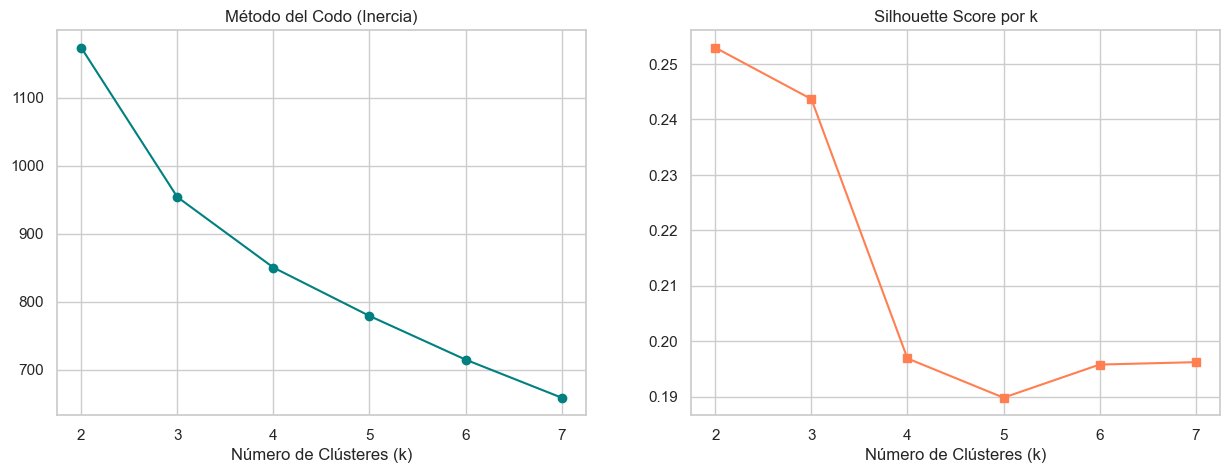

In [1]:
# --- 1. COMPARACIÓN DE CONFIGURACIONES (Buscando el K ideal) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")

# Cargar los datos procesados por el Feature Pipeline
df_scaled = pd.read_csv("../data/processed/wholesale_customers_scaled.csv")

inercia = []
silhouette_scores = []
rango_k = range(2, 8) # Probaremos desde 2 hasta 7 grupos

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    inercia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(rango_k, inercia, marker='o', color='teal')
ax1.set_title('Método del Codo (Inercia)')
ax1.set_xlabel('Número de Clústeres (k)')

ax2.plot(rango_k, silhouette_scores, marker='s', color='coral')
ax2.set_title('Silhouette Score por k')
ax2.set_xlabel('Número de Clústeres (k)')
plt.show()

### Decisión de Configuración del Modelo
* **Justificación:** El Método del Codo muestra una inflexión alrededor de k=3, mientras que el Silhouette Score confirma que esta configuración mantiene un equilibrio razonable en la cohesión y separación de los grupos. Por lo tanto, validamos **k=3** como la configuración óptima para nuestro baseline en `train.py`.

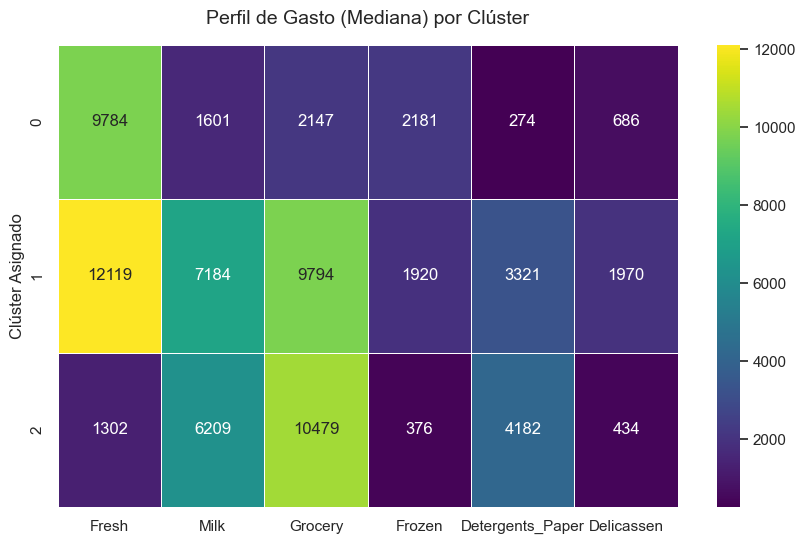

In [2]:
# --- 2. INTERPRETACIÓN DE LOS CLUSTERS ---
import joblib

# 1. Cargamos los datos originales (sin escalar) para ver el dinero real
df_original = pd.read_csv("../data/raw/wholesale_customers.csv")
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# 2. Cargamos el modelo que acabas de entrenar
model = joblib.load("../models/baseline_kmeans.pkl")

# 3. Asignamos a cada cliente su cluster correspondiente
df_original['Cluster'] = model.predict(df_scaled)

# 4. Calculamos la mediana de gasto por cada grupo
cluster_profiles = df_original.groupby('Cluster')[spending_cols].median()

# Visualizamos el perfil con un Mapa de Calor
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles, annot=True, fmt=".0f", cmap="viridis", linewidths=0.5)
plt.title("Perfil de Gasto (Mediana) por Clúster", fontsize=14, pad=15)
plt.ylabel("Clúster Asignado")
plt.show()

### nterpretación Final de los Clústeres
El algoritmo descubrió de forma no supervisada 3 perfiles distintos de clientes:
* **Clúster 0:** Concentran su gasto fuertemente en Abarrotes (`Grocery`), Leche (`Milk`) y Detergentes. Corresponden al perfil clásico de **Minimarkets y Tiendas de Conveniencia**.
* **Clúster 1:** Su gasto está dominado casi en su totalidad por productos Frescos (`Fresh`). Este perfil encaja con **Restaurantes y Cafeterías** que requieren insumos del día.
* **Clúster 2:** Representan a los clientes con gastos moderados y balanceados en todas las categorías, perfilándose como **Pequeños Compradores o Negocios Diversificados**.